Model Performance:
MSE : 2806426667.247852
RMSE: 52975.717713381215


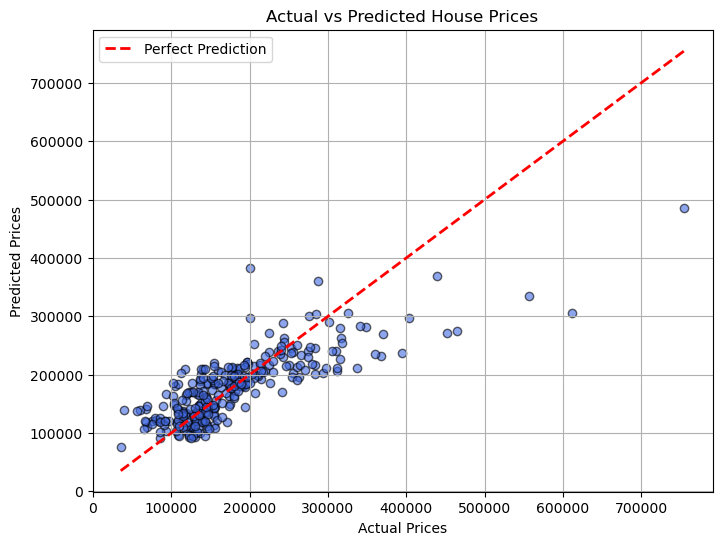


✅ Task Completed Successfully
📁 submission.csv generated


In [2]:
# ==========================================
# TASK 01: Linear Regression - House Prices
# ==========================================

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Clean column names
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

# ------------------------------------------
# 2. Select Features (as per task)
# ------------------------------------------
features = ["GrLivArea", "BedroomAbvGr", "FullBath"]
target = "SalePrice"

X = train[features]
y = train[target]

# ------------------------------------------
# 3. Handle Missing Values
# ------------------------------------------
X = X.fillna(X.median())
test[features] = test[features].fillna(X.median())

# ------------------------------------------
# 4. Split Data
# ------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------
# 5. Train Model
# ------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ------------------------------------------
# 6. Predictions
# ------------------------------------------
y_pred = model.predict(X_val)

# ------------------------------------------
# 7. Evaluation
# ------------------------------------------
mse = mean_squared_error(y_val, y_pred)
rmse = mse ** 0.5

print("Model Performance:")
print("MSE :", mse)
print("RMSE:", rmse)

# ------------------------------------------
# 8. Predicted vs Actual Graph (Improved)
# ------------------------------------------
plt.figure(figsize=(8,6))

# Scatter plot with styling
plt.scatter(y_val, y_pred, color='royalblue', alpha=0.6, edgecolor='k')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

# Perfect prediction line (in red dashed)
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color='red',
    linestyle='--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------
# 9. Predict on Test Data
# ------------------------------------------
X_test = test[features]
test_predictions = model.predict(X_test)

# ------------------------------------------
# 10. Save Submission
# ------------------------------------------
output = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_predictions
})

output.to_csv("submission.csv", index=False)

print("\n✅ Task Completed Successfully")
print("📁 submission.csv generated")